In [1]:
import ROOT as rt
import sys
import collections
from collections import OrderedDict
import uproot
import pandas as pd


import scipy
import awkward
import time

import subprocess
GIT_REPO = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'], stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8')
sys.path.append(GIT_REPO + '/lib/')
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
from helper_functions import *

import numpy as np
from scipy.stats import norm
import math
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()
CMS_lumi.writeExtraText = 0

from pathlib import Path
# donotdelete = []
print(sys.version)

Welcome to JupyROOT 6.24/06
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


In [2]:
%%time

fpath =OrderedDict()
tree = OrderedDict()
accep_cscdt = OrderedDict()
accep_csccsc = OrderedDict()
start_t = time.time()

# for data_year in ['2022','2023','all']:
version = 'v25'
LUMI_SCALE = 2.84
# for data_year in ['all']:

#     # path = "/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/data/raw/"
#     # fpath_bkg[data_year] = path + f"data_{data_year}_goodLumi.root"
#     if data_year == 'all':path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/{version}/normalized/'
#     else: path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data{data_year}/{version}/normalized/'
#     if data_year == '2022':fpath['data'+data_year] = path + "DisplacedJet-EXOCSCCluster_Run2022-PromptReco_goodLumi.root"
#     elif data_year == '2023':fpath['data'+data_year] = path + "Muon-EXOCSCCluster_Run2023-PromptReco_goodLumi.root"
#     elif data_year == '2024':fpath['data'+data_year] = path + "Muon-Run2024-PromptReco_goodLumi.root"
#     elif data_year == 'all':fpath['data'+data_year] = path + "EXOCSCCluster_Run2022_2024_goodLumi.root"

# for m in [15, 40]:
    
# # fpath['sig'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root'
#     fpath[f'{m}'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4D_MH-125-MS-{m}-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root'
# fpath['sig_tau'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4Tau_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root'
# fpath['sig_d'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v19/normalized/ggH_Hto2Sto4D_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root'
fpath['HV_25'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_Summer22EE/v25/normalized/HiddenValley_higgs_m_15_ctau_1000_xiO_2p5_xiL_1_23020pb_weighted.root'
fpath['HV_26'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_Summer22EE/v26/normalized/HiddenValley_higgs_m_15_ctau_1000_xiO_2p5_xiL_1_23020pb_weighted.root'
# fpath['HV_10'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_Summer22EE/{version}/normalized/HiddenValley_higgs_m_15_ctau_10000_xiO_2p5_xiL_1_23020pb_weighted.root'

NEvents = {}

for k,v in fpath.items():
    print (k, v)
    root_dir = uproot.open(v) 

    tree[k] = root_dir['MuonSystem']
    NEvents[k] = root_dir['NEvents'].values()[0]
    if not "data" in k:
        accep_csccsc[k] = root_dir['accep_csccsc'].values()[0]
        accep_cscdt[k] = root_dir['accep_cscdt'].values()[0]
    # NEvents[k] = root_dir['NEvents'].values()[0]
    # NEvents[k] = root_dir['NEvents'].counts()
    print("NEvents",NEvents[k])


HV_25 /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_Summer22EE/v25/normalized/HiddenValley_higgs_m_15_ctau_1000_xiO_2p5_xiL_1_23020pb_weighted.root
NEvents 46315424.0
HV_26 /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_Summer22EE/v26/normalized/HiddenValley_higgs_m_15_ctau_1000_xiO_2p5_xiL_1_23020pb_weighted.root
NEvents 46180410.0
CPU times: user 402 ms, sys: 7.91 ms, total: 410 ms
Wall time: 416 ms


In [18]:
tree.keys()

odict_keys(['HV_25', 'HV_26'])

In [ ]:
for branch in T.keys():
    for k,T in tree.items():
        # print(k, T['evtNum'].array()[:10])
        cond = T['evtNum'].array() == 68955
        print(k, branch, T[branch].array()[cond])


In [26]:
%%time


nCscRechitClusters_nocut = {}
nDtRechitClusters_nocut = {}

cscRechitClusterPhi = {}
cscRechitClusterTime = {}
cscRechitClusterSize = {}
cscRechitClusterEta = {}
dtRechitClusterSize = {}
dtRechitClusterBX = {}
cscRechitClusterNStation = {}
Puppimet = {}
for k in tree.keys():
    T = tree[k]

    nCscRechitClusters_nocut[k] = T['nCscRechitClusters_nocut'].array()
    nDtRechitClusters_nocut[k] = T['nDtRechitClusters_nocut'].array()

    cscRechitClusterPhi[k] = T['cscRechitClusterPhi'].array()
    cscRechitClusterTime[k] = T['cscRechitClusterTimeWeighted'].array()
    cscRechitClusterSize[k] = T['cscRechitClusterSize'].array()
    cscRechitClusterEta[k] = T['cscRechitClusterEta'].array()
    dtRechitClusterSize[k] = T['dtRechitClusterSize'].array()
    dtRechitClusterBX[k] = T['dtRechitCluster_match_RPCBx_dPhi0p5'].array()
    cscRechitClusterNStation[k] = T['cscRechitClusterNStation10'].array()

    Puppimet[k] = T['Puppimet'].array()

CPU times: user 1.59 s, sys: 46.2 ms, total: 1.64 s
Wall time: 1.64 s


In [20]:
Puppimet.keys()

dict_keys(['HV_26'])

In [27]:
variables = {
'nCscRechitClusters_nocut': ['N csc cluster', nCscRechitClusters_nocut, [5,0,5], True],
'nDtRechitClusters_nocut': ['N dt cluster', nDtRechitClusters_nocut, [5,0,5], True],

'cscRechitClusterPhi': ['CSC cluster #phi', cscRechitClusterPhi, [50,-3.5,3.5], True],
'cscRechitClusterEta': ['CSC cluster #eta', cscRechitClusterEta, [50,-3,3], True],
'cscRechitClusterTime': ['CSC cluster time [ns]', cscRechitClusterTime, [50,-100,100], False],
'cscRechitClusterSize': ['CSC cluster N_{hits}', cscRechitClusterSize, [50,0,500], True],

'dtRechitClusterSize': ['DT cluster N_{hits}', dtRechitClusterSize, [50,0,500], True],
'dtRechitClusterBX': ['DT cluster bunch crossing', dtRechitClusterBX, [10,-5,5], False],

'Puppimet': ['MET [GeV]',Puppimet,[50,0,200],True],

}


plot_dir = GIT_REPO + f"/plots/validate_mds/"
Path(plot_dir).mkdir(parents=True, exist_ok=True)

nCscRechitClusters_nocut
HV_25
here
HV_26
here
nDtRechitClusters_nocut
HV_25
here
HV_26
here
cscRechitClusterPhi
HV_25
HV_26
cscRechitClusterEta
HV_25
HV_26
cscRechitClusterTime
HV_25
HV_26
cscRechitClusterSize
HV_25
HV_26
dtRechitClusterSize
HV_25
HV_26
dtRechitClusterBX
HV_25
HV_26
Puppimet
HV_25
here
HV_26
here
0.7836639881134033


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/validate_mds//nCscRechitClusters_nocut.png has been created
Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/validate_mds//nCscRechitClusters_nocut.pdf has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/validate_mds//nCscRechitClusters_nocut.C has been generated
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/validate_mds//nDtRec

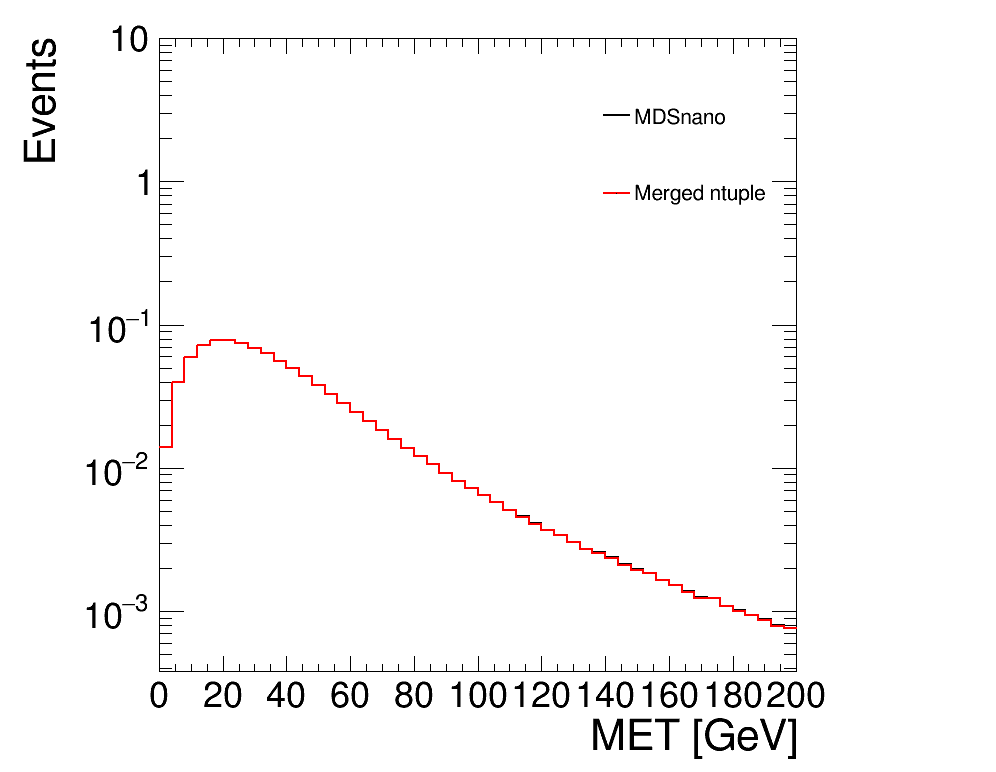

In [28]:

start_t = time.time()
for name, v in variables.items():

    c = rt.TCanvas('c','c', 1000, 800)
    h = {}
    leg = rt.TLegend(0.6,0.7,0.75,0.9)
    leg.SetTextSize(0.03)
    leg.SetTextFont(42)
    leg.SetBorderSize(0)
    xaxis, plot_var, bins, logy = v
    i = 0
    print(name)
    for k in plot_var.keys():
        print(k)
        # if "data" in k and selections >= 2:
        if not "_nocut" in name and not "met" in name: h[k] = create_TH1D( np.array(ak.flatten(plot_var[k])), axis_title = [xaxis,'Events'], binning=bins)
        else:
            print("here")
            h[k] = create_TH1D( np.array(plot_var[k]), axis_title = [xaxis,'Events'], binning=bins)
        h[k].Scale(1./h[k].Integral())
        if logy: h[k].SetMaximum(10)
        else: h[k].SetMaximum(1.2)
        if "25" in k:leg.AddEntry(h[k],"MDSnano")
        else: leg.AddEntry(h[k],"Merged ntuple")
        h[k].SetLineColor(std_color_list[i])
        
        
        h[k].Draw('hist same')
        i+=1
    c.SetRightMargin(0.2)

    if logy: c.SetLogy()
    leg.Draw()
    c.Draw()

    c.SaveAs(plot_dir + f"/{name}.png")
    c.SaveAs(plot_dir + f"/{name}.pdf")
    c.SaveAs(plot_dir + f"/{name}.C")

print(time.time()-start_t)


In [8]:
nCscRechitClusters_nocut[k]